# Authorship Verification

## Loading in the needed libraries

In [22]:
import os
import re
from collections import Counter
import glob
from itertools import combinations, product
from bokeh.io import output_file, save

import lxml.etree
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
pd.set_option('display.max_colwidth', 0)
import numpy as np
np.random.seed(18012023)
import seaborn as sb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import scipy.spatial.distance as scidist

from bokeh.models import HoverTool, ColumnDataSource
from bokeh.plotting import figure, show, output_file, save
from bokeh.io import output_file, show, save, output_notebook
from bokeh.plotting import figure
from bokeh.models import Axis

from adjustText import adjust_text

import mpl_axes_aligner

## Loading in the data and metadata

In [23]:
def load_verses(filepath, rm_interpol=True):    
    tree = lxml.etree.parse(filepath)
    
    if rm_interpol:
        for interpolation in tree.xpath("//interpolation"):
            interpolation.getparent().remove(interpolation)
    
    verses = []
    
    for line_node in tree.iterfind('.//l'):
        verse = []
        
        lemma_tags = [l.text if l.text else "" for l in line_node.iterfind('.//lemma')]
        pos_tags = [p.text if p.text else "" for p in line_node.iterfind('.//pos')]
        
        for lemma, pos in zip(lemma_tags, pos_tags):
            lemma = lemma or ""  # Ensure lemma is not None
            pos = pos or ""      # Ensure pos is not None
            
            for l, p in zip(lemma.split('+'), pos.split('+')):
                if p == 'NOU-P':
                    verse.append(('NOU-P', 'NOU-P'))
                else:
                    verse.append((l, p))
        
        verses.append(verse)
    
    return verses

In [28]:
meta_df = pd.read_excel('../data/metadata_corrected.xlsx')
meta_df = meta_df[meta_df['genre'] == 'Epiek']
meta_df = meta_df[meta_df['exclude'] != 'x']
meta_df.sample(10)

,id,title,author,provenance,date_range,genre,subgenre,exclude
271,korte_kroniek_van_brabant_korte_versie_2,Vande Hertogen ende Heeren van Brabant,NaN,cdrom-mnl,1570-1590,Epiek,Historiografie,NaN
12,beerte_metten_breden_voeten,Beerte metten breden voeten,NaN,cdrom-mnl,1375-1425,Epiek,Karel,NaN
23,borchgravinne_van_vergi__1,Borchgravinne van Vergi (1),NaN,cdrom-mnl,1400-1420,Epiek,Ridder,NaN
88,Merlijn-Maerlant,Merlijn,Jacob van Maerlant,cdrom-mnl,1415-1435,Epiek,Arthur,NaN
218,spiegel_historiael__1_3_4_maerlant,Spiegel historiael (P1-P4),Jacob van Maerlant,cdrom-mnl,1300-1325,Epiek,Historiografie,NaN
287,Merlijn-Velthem,Merlijn-continuatie,Lodewijk van Velthem,cdrom-mnl,1415-1435,Epiek,Arthur,NaN
229,spiegel_historiael__4_velthem__fragm_ge4,Spiegel historiael (P4),Lodewijk van Velthem,cdrom-mnl,1390-1410,Epiek,Historiografie,NaN
231,spiegel_historiael__4_velthem__fragm_ge7,Spiegel historiael (P4),Lodewijk van Velthem,cdrom-mnl,1390-1410,Epiek,Historiografie,NaN
93,roman_van_iechemas,Iechemas,NaN,cdrom-mnl,1340-1360,Epiek,Ridder,NaN
80,grimbergse_oorlog_cont,Grimbergse oorlog (cont),NaN,cdrom-mnl,1300-1350,Epiek,Historiografie,NaN


In [29]:
works = []
rm_interpol = True

pbar = tqdm(meta_df.groupby('title'), desc='description')
for title, group in pbar:
    pbar.set_description('{message: <{width}}'.format(message=title[:50], width=50))
    meta = list(group.sample(1)[['title', 'author', 'genre', 'subgenre']].values[0])
    words = []
    
    for id_ in sorted(group['id']):
        try:
            words.extend(load_verses(f'../data/xml_galahad_BY-split/{id_}.xml', rm_interpol=rm_interpol))
        except OSError:
            print(f'- Could not load {id_}')
            continue
    
    works.append(meta + [words])

work_df = pd.DataFrame(works, columns=['title', 'author', 'genre', 'subgenre', 'text'])

Wrake van Ragisel                                 : 100%|█| 165/165 [00:08<00:0


## Segmentation 

In [30]:
len(work_df[work_df['title'].str.contains('Eduwaert')]['text'].iloc[0])

2018

In [31]:
len(work_df[work_df['title'].str.contains('Melibeus')]['text'].iloc[0])

3772

In [32]:
def segment(work_df, rhyme_only=True, incl_lemma=True, incl_pos=False, segment_length = 2000, min_length=1364):        
    if not (incl_pos or incl_lemma):
        raise ValueError('incl_lemma OR incl_pos must be set to True')

    segments = []

    for _, row in tqdm(list(work_df.iterrows())):
        if rhyme_only:
            text = [verse[-1] for verse in row['text']]
        else:
            text = [item for sublist in row['text'] for item in sublist]
        
        if incl_lemma and incl_pos:
            text = ['@'.join(p) for p in text]
        elif incl_lemma:
            text = [p[0] for p in text]
        else:
            text = [p[1] for p in text]

        meta = [row['title'], row['author'], row['genre'], row['subgenre']]
        
        if row['title'] == 'Van Saladijn':
            text = text[::2] + text[1::2]
        
        if segment_length:
            if len(text) < segment_length:
                continue
            si, ei, idx = 0, segment_length, 1
            while ei < len(text):
                segments.append(meta + [idx, text[si:ei]])
                idx += 1
                si += segment_length
                ei += segment_length
        else:
            if len(text) >= min_length:
                segments.append(meta + [0, text])

    return pd.DataFrame(segments, columns=['title', 'author', 'genre', 'subgenre', 'segment-idx', 'text'])

segment_df = segment(work_df, rhyme_only=True, incl_pos=False, segment_length=1800) # So that at least one segment of Van den derden Eduwaert is included and two of Melibeus – the two shortest works in the Antwerp School
# lower segment length to 1400 to include Grimbergse oorlog continuation

100%|██████████████████████████████████████| 165/165 [00:00<00:00, 2172.51it/s]


In [33]:
segment_df

,title,author,genre,subgenre,segment-idx,text
0,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,1,"[zede, stede, horen, verdoren, goed, doen, verstaan, waan, geraakt, maken, lof, af, verkeren, leren, goed, doen, deugd, mogen, leren, keren, verstaan, baraat, bestaan, vangen, geest, volleesten, verstaan, slaan, roek, boek, zagen, dag, beschrijven, leven, lijf, wijf, maken, raken, oorlog, togen, zijn, dwassen, hebben, leven, lieden, geschieden, wind, vinden, avontuur, artuur, NOU-P, klein, spel, gevallen, Hun, gestuinen, zijn, jaar, dwingen, lang, toe, hoe, bestaan, goed, voren, horen, zin, min, moeten, zoet, geslacht, macht, voren, geboren, geweld, behouden, onderdaan, ontvangen, NOU-P, prijs, aardrijk, rijk, NOU-P, vrij, doorvacht, kracht, held, weld, overslaan, gaan, land, hand, schip, NOU-P, jaar, waar, blijven, beschrijven, vrouwe, trouw, ...]"
1,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,2,"[zaan, dwaan, koud, menigvout, hand, vinden, tijd, lijden, kracht, onmacht, uiten, luid, dingen, jongeling, verdienen, vriend, naakt, staken, avontuur, sturen, vinden, wind, NOU-P, gewinnen, fel, wel, dan, man, moeder, stiefmoeder, deze, wezen, gader, vader, schaar, haar, land, brand, lijfneer, weer, bestaan, waan, aarde, weren, dat, zitten, wiel, vallen, heer, meer, katijf, lijf, zien, lachen, heer, immermeer, griek, zieke, mond, stonde, vervaard, waard, dol, vol, moeien, vernooien, natuur, avontuur, recht, knecht, lof, of, brengen, mogen, natuur, avontuur, blijven, drijven, ongestade, schade, bijten, heten, stonde, mond, doch, nog, beide, zerigheid, ongeval, zullen, slaan, waan, onzien, fisiciën, tijd, beiden, ongeval, al, afhebben, lof, ...]"
2,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,3,"[land, sant, worm, storm, gebaar, zijn, reen, engeen, rivier, manier, waar, aldaar, na, NOU-P, kerk, gewerk, staan, raad, gebed, zeggen, zijn, openbaar, waan, vergaan, voren, verkiezen, zijn, varen, schaar, zijn, zand, eiland, hoog, droog, zee, wee, zand, land, land, sant, nacht, onzacht, vernemen, komen, drinken, lang, opgang, lang, koud, zullen, neder, weder, middernacht, kracht, gaan, ontvangen, natuur, zuur, fontein, rein, drinken, zinken, staan, zaan, openbaar, zijn, liegen, bedriegen, strijd, tijd, blij, zijde, ontvaren, zijn, man, onnen, NOU-P, NOU-P, land, altehand, koninkrijk, aardrijk, nieuwmare, zijn, wijg, prijg, al, zullen, winnen, man, mede, stede, getal, wel, heer, weer, koninkrijk, aardrijk, komen, nemen, ...]"
3,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,4,"[ding, koning, staan, waan, sale, altemaal, stroom, droom, maan, waan, zege, allerwegen, naam, bekwaam, pilaar, openbaar, wijsheid, gereden, zekerlijk, aardrijk, ander, NOU-P, zeggen, allerwegen, gedoogzaamheid, zede, zuur, avontuur, kracht, macht, voet, gemoeten, sale, wel, harre, ver, kennen, gewinnen, daad, stade, gierigheid, zede, bestaan, ontvangen, paleis, pais, al, al, mild, willen, lauwerbloem, droom, daar, openbaar, eer, nimmermeer, zege, allerwegen, mogendheid, stede, bedwang, omgang, naar, vaar, rechte, lichten, stede, gerechtigheid, bij, vrij, gestade, raad, zitten, weten, zonde, stond, eenradigheid, stad, hoog, oorlog, voet, zoet, onnen, kunne, NOU-P, na, verleden, staan, staan, waan, allerwegen, zeggen, NOU-P, na, verzien, lachen, eer, zeer, willen, behouden, ...]"
4,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,5,"[de, lid, stede, zeer, meer, mogen, dag, ontvangen, ontgaan, horen, antwoorden, schofferen, tebarenteren, willen, stil, hebben, leven, nacht, achten, lijf, katijven, NOU-P, zijn, baden, doen, openbaar, zijn, zijn, dat, nicht, licht, knecht, recht, avontuur, bezuren, overmoed, doen, wezen, deze, vriend, verdienen, hopen, kopen, wet, bet, vangen, waan, koningin, zin, vernooien, mooi, NOU-P, dissen, slaan, gaan, vinden, vijand, beschrijven, wijf, niet, geschieden, stede, mede, moet, staan, stede, mede, kavel, gavel, door, avontuur, stede, bede, vrijen, uxie, doen, ontvangen, vrijheid, gerei, permenioen, koen, vijand, land, lis

## Combinations

In [34]:
calib_df = segment_df[
    (segment_df['author'].isin({'Jacob van Maerlant', 'Lodewijk van Velthem'})) | 
    (segment_df['title'].isin({'Jans teesteye'}))]                                           
calib_df = calib_df[calib_df['title'] != 'Torec']
calib_df = calib_df[calib_df['title'] != 'Merlijn']
#calib_df = calib_df[calib_df['title'] != 'Heymelijchede der heymelijcheit']

trg_df = segment_df[segment_df['title'].isin({#'Brabantsche yeesten (B1-3)', 
                                              #'Brabantsche yeesten (B4-5)',
                                              'Brabantsche yeesten (B5)',
                                              'Der leken spieghel',
                                              'Jans teesteye',
                                              'Van den derden Eduwaert',
                                              'Melibeus',
                                              'Dietsche doctrinale',
                                              'Boec vander wraken',
                                              #'Der ystorien bloeme',
                                              #'Grimbergse oorlog'
                                             })]

Option to compare *Der ystorien bloeme* to Velthem's oeuvre

### Interpolations

The following interpolations are removed from the works. Based on Vandyck, C., & Kestemont, M. (2024). Een auteur van formaat. Een attributie-onderzoek naar het oeuvre van de Limborch-dichter. Spiegel Der Letteren, 66(2), 111–167. https://doi.org/10.2143/SDL.66.2.3293546)

Historie van Troyen (De Pauw & Gailliard 1889-1892, vs. 14587, vs. 16492, vs. 28332)

* vanaf vs. 14591 (Dies is leden menghen dach) t.e.m. vs. 15858 (Sonder haere beider lachter), ed. De Pauw & Gailliard 1889-1892.
* vanaf vs. 16493 (Daer waster veel syt, seker des) t.e.m. vs. 17500 (Dat seit Dares diet ons bescreef.), ed. De Pauw & Gailliard 1889-1892.
* vanaf vs. 28336 (Die werlt is gedeilt in drien) t.e.m. vs. 29344 (Sy en doyet gheen tyt), ed. De Pauw & Gailliard 1889-1892.

Spiegel Historiael, Vijfde Partie (Besamusca 2009, 83)

* vanaf boek I, kap. 40-46, vs. 2818 (Die derde Heinric van Brabant) t.e.m. vs. 3543 (Mar hier gaen vore ander dinge), ed. Vander Linden e.a. 1906-1938
* vanaf boek II, kap. 44-55, vs. 3213 (Na dit doen, dit es waer) t.e.m. vs. 3976 (Ward met enen stride gehint), ed. Vander Linden e.a. 1906-1938. 
* vanaf boek III, kap. 2-21, vs. 71 (In desen tiden, alse nu, gelach) t.e.m. vs. 1403 (In andren landen ende andren lieden), ed. Vander Linden e.a. 1906-1938.
* vanaf boek IV, vs. 1 (Nu es die tijt so verre comen) t.e.m. vs. 5329 (Den viften boec ende, ende volmaken), ed. Vander Linden e.a. 1906-1938.

Boec vander Wrake (Van Anrooij 1995, 44)

* vanaf boek III, vs. 2273 (Die hem wel bepeynsen soude) t.e.m. vs. 2490 (Amen seghet allegader. Amen), ed. Snellaert 1869.

Der vrouwen heimelijcheit (Van Doorn & Kuiper 1976-1977, 539) 
* vanaf vs. 824 (Ic soude u leeren, sonder waen) t.e.m. vs. 925 (Maer van den magdekine niet so saen,), ed. Blommaert 1846.

Dietsche Lucidarius (Klunder 2005, 80-88)30
* vanaf vs. 357 (Clerc, die here, die niene verstarf ) t.e.m. vs. 436 (Om die genuechte van aertrike), ed. Blommaert 1851.
* vanaf vs. 889 (Lieve meester, maect mi wijs) t.e.m. vs. 1026 (Mit saligen sielen scone;), ed. Blommaert 1851.
* vanaf vs. 4680 (Of men den lichame in ’t kerchof ) t.e.m. vs. 4810 (Daer die engelen Gode loven), ed. Blommaert 1851.

We also marked two extra interpolations, based on our findings in notebook 03-intertext-macro:
* Boec van der wraken: vs. 5621-5836 (parallel with passage in Jans teesteye)
* Brabantsche yeesten (B5): book V vs. 3987-4154 (parallel with passage in Van den derden Eduwaert)

Grimbergse oorlog (Croenen, 2005):
* It is thought that this work was written by one author, and finished by another. Accordingly, the work was split up into Grimbergse oorlog and Grimbergse oorlog (cont). Verse 1-502 of Grimbergse oorlog were left out, since it is unsure whether this prologue was written by the first or the second author.

In [35]:
calib_df[['author', 'title']].value_counts()

author                title                          
Jacob van Maerlant    Spiegel historiael (P1-P4)         49
                      Historie van Troyen                20
                      Rijmbijbel                         19
Lodewijk van Velthem  Merlijn-continuatie                14
                      Spiegel historiael (P5)            10
Jacob van Maerlant    Der naturen bloeme                 9 
                      Alexanders geesten                 7 
                      Sinte Franciscus leven             5 
Lodewijk van Velthem  Spiegel historiael (P4)            3 
Jan van Boendale      Jans teesteye                      2 
Jacob van Maerlant    Heymelijchede der heymelijcheit    1 
Name: count, dtype: int64

In [36]:
trg_df[['title']].value_counts()

title                   
Der leken spieghel          12
Boec vander wraken          3 
Dietsche doctrinale         3 
Brabantsche yeesten (B5)    2 
Jans teesteye               2 
Melibeus                    2 
Van den derden Eduwaert     1 
Name: count, dtype: int64

In [37]:
combos = []
authors_titles = [g for g, _ in calib_df.groupby(['author', 'title'])]
for c1, c2 in combinations(authors_titles, 2):
    if c1[0] == c2[0]:
        combos.append((c1[1], c2[1], 'S'))
    else:
        combos.append((c1[1], c2[1], 'D'))

combos = pd.DataFrame(combos, columns=['title1', 'title2', 'authorship'])
print(combos['authorship'].value_counts())
combos.sample(5)

authorship
D    31
S    24
Name: count, dtype: int64


,title1,title2,authorship
26,Heymelijchede der heymelijcheit,Spiegel historiael (P5),D
21,Heymelijchede der heymelijcheit,Sinte Franciscus leven,S
0,Alexanders geesten,Der naturen bloeme,S
8,Alexanders geesten,Spiegel historiael (P4),D
16,Der naturen bloeme,Merlijn-continuatie,D


In [38]:
def identity(x):
    return x

def bigrams(text):
    for i in range(len(text)-1):
        if 'NOU-P' not in text[i:i+2]:
            yield '-'.join((sorted(text[i:i+2])))
            
def unigrams(text):
    for i in range(len(text)):
        if 'NOU-P' not in text[i]:
            yield text[i]
            
params = {'use_idf': True,
          'max_features': 500,
          'analyzer': bigrams,
          'min_df': 2}

vectorizer = TfidfVectorizer(**params)
vectorizer.fit(list(calib_df['text']) + list(trg_df['text']))
X = vectorizer.transform(calib_df['text']).toarray()
X.shape

(139, 500)

In [39]:
# Sanity check to make sure all proper nouns are ignored and not present in the vector (important for Korte Kroniek)

# get the features from the vectorizer
feature_names = vectorizer.get_feature_names_out()
contains_nou_p = any("NOU-P" in feature for feature in feature_names)

# result
print("Does the feature list contain 'NOU-P'?", contains_nou_p)

Does the feature list contain 'NOU-P'? False


## Authorship Verification

### Calibration

In [40]:
calib_distances = []

for idx, row in combos.iterrows():
    AX = X[calib_df['title'] == row['title1']]
    BX = X[calib_df['title'] == row['title2']]
    
    for distance in scidist.cdist(AX, BX, metric='cosine').flatten():
        calib_distances.append((row['title1'], row['title2'], row['authorship'], distance))

calib_distances = pd.DataFrame(calib_distances, columns=['title1', 'title2', 'authorship', 'distance'])
calib_distances = calib_distances[~calib_distances['distance'].isna()]
calib_distances

,title1,title2,authorship,distance
0,Alexanders geesten,Der naturen bloeme,S,0.777108
1,Alexanders geesten,Der naturen bloeme,S,0.759969
2,Alexanders geesten,Der naturen bloeme,S,0.806501
3,Alexanders geesten,Der naturen bloeme,S,0.804917
4,Alexanders geesten,Der naturen bloeme,S,0.790790
...,...,...,...,...
7842,Spiegel historiael (P4),Spiegel historiael (P5),S,0.481753
7843,Spiegel historiael (P4),Spiegel historiael (P5),S,0.403220
7844,Spiegel historiael (P4),Spiegel historiael (P5),S,0.376205
7845,Spiegel historiael (P4),Spiegel historiael (P5),S,0.439391


max(f1)=0.0 @ theta=0.257


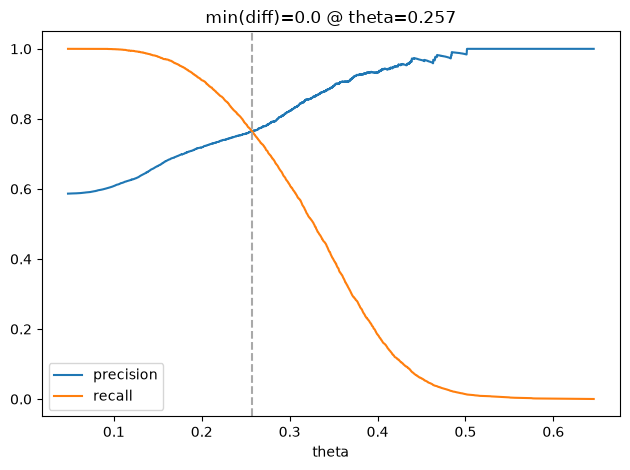

In [41]:
distances = 1 - np.array(calib_distances['distance'])
relevances = calib_distances['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [42]:
calib_thresh = 1 - max_diff_th
calib_thresh

np.float64(0.743049404830946)

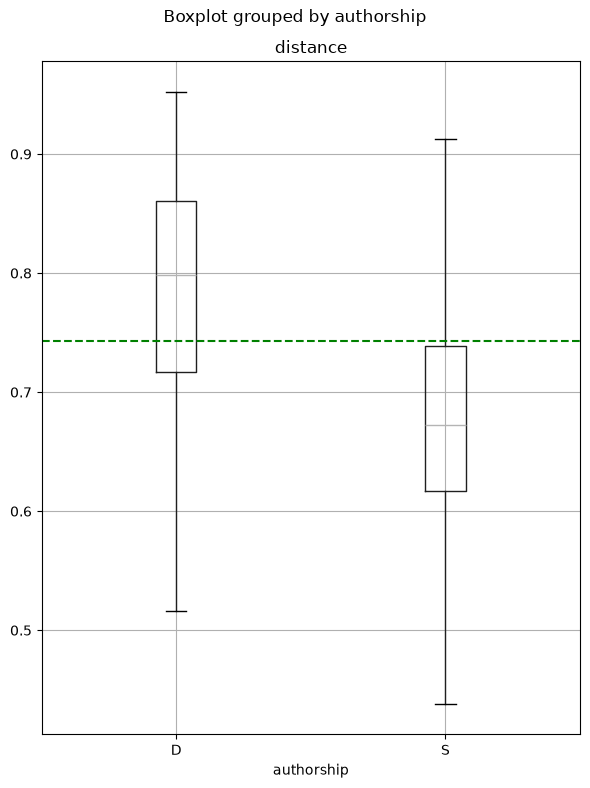

In [43]:
calib_distances.boxplot('distance', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

### Applied to Antwerp School

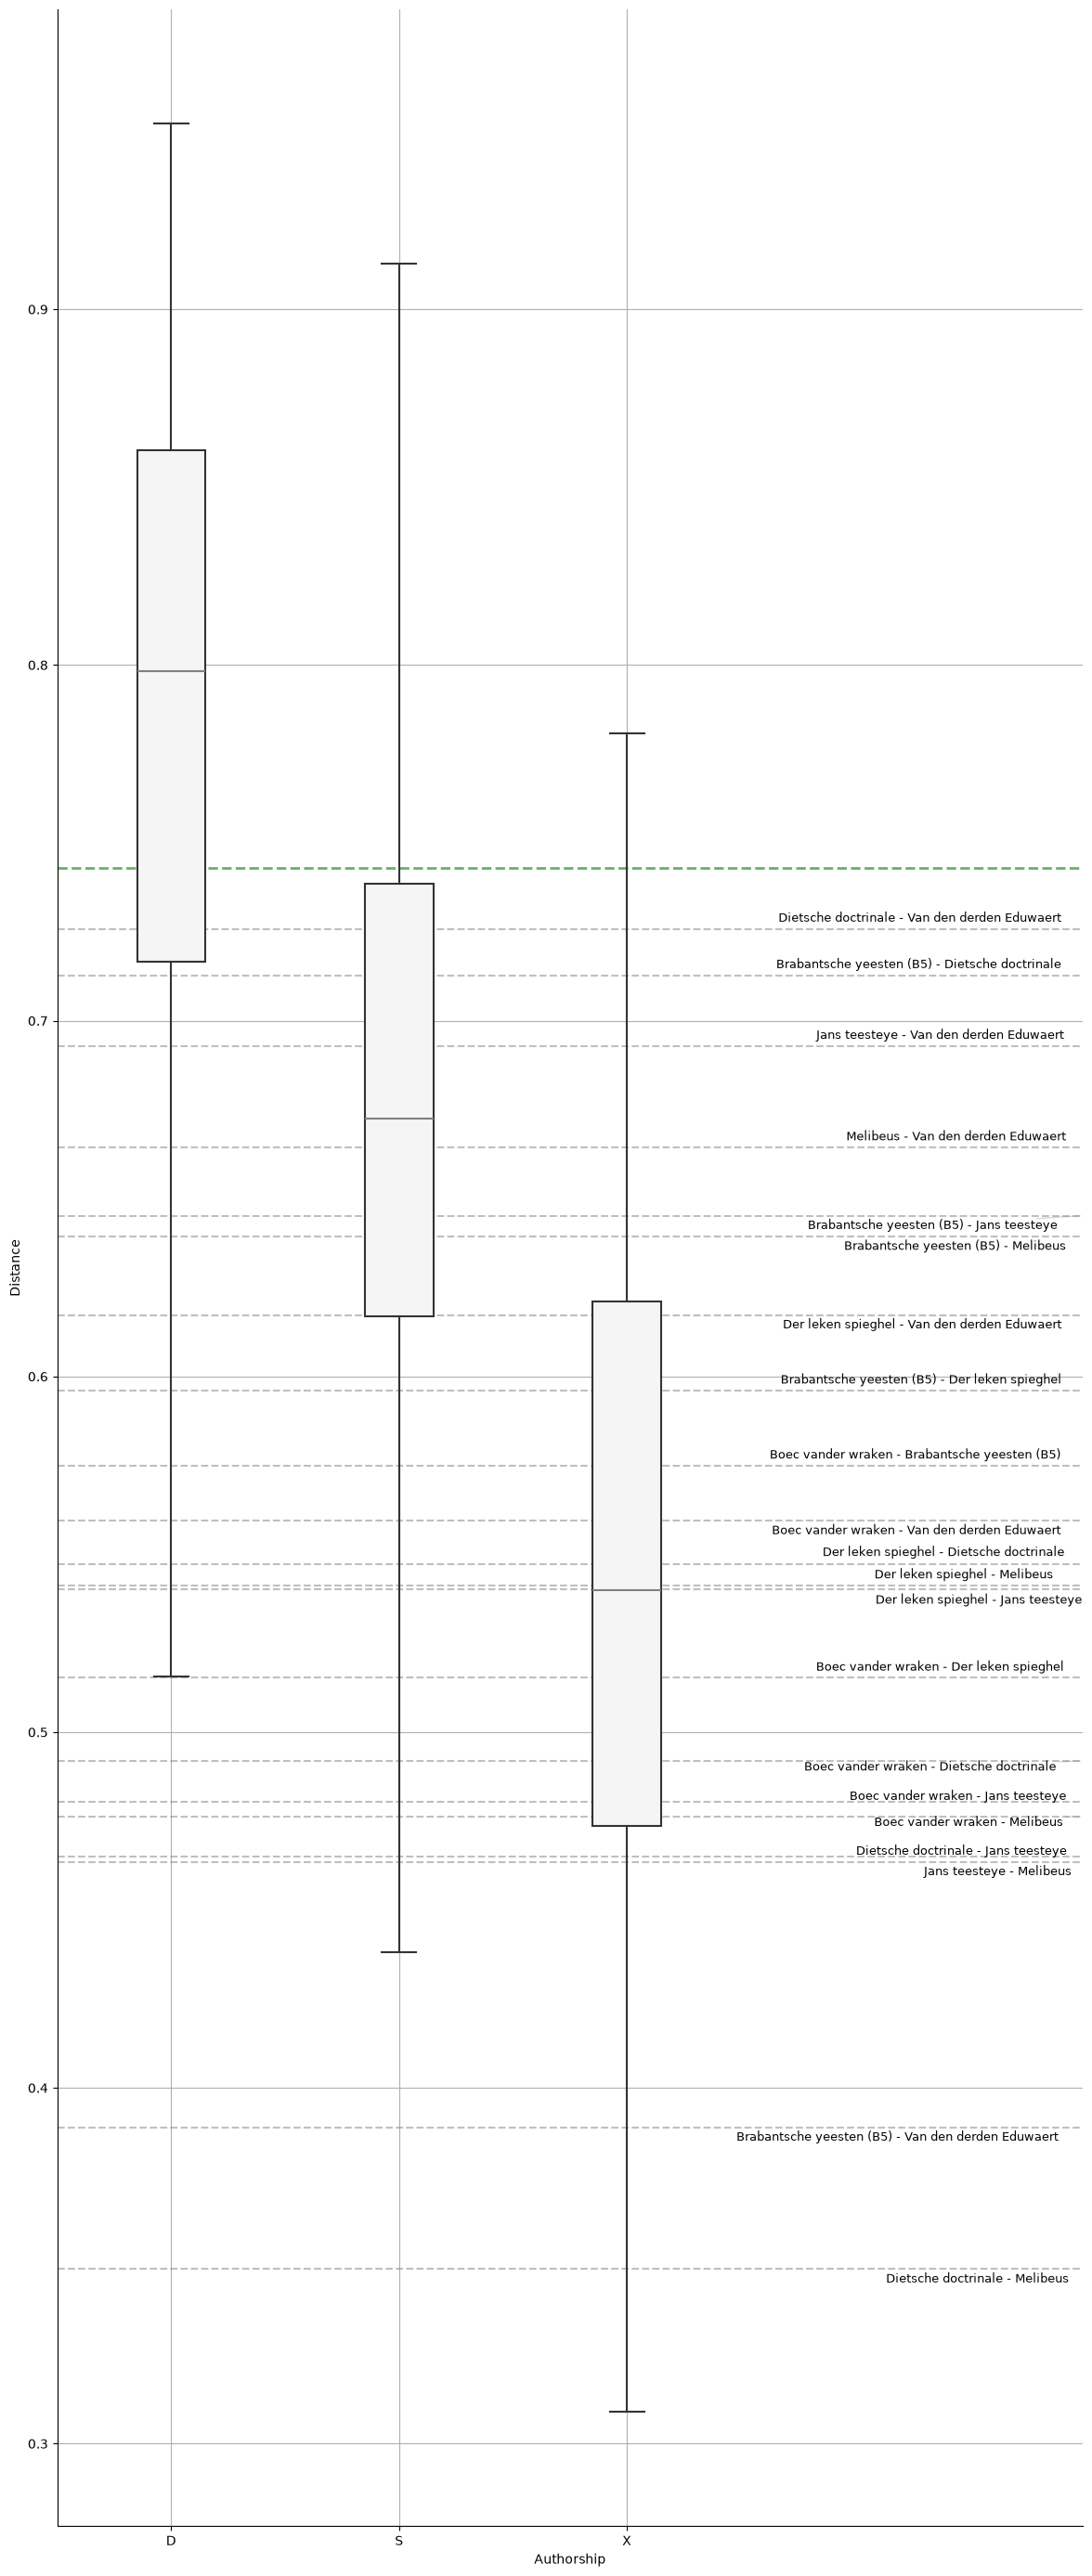

In [44]:
# compute distances

trg_X = vectorizer.transform(trg_df['text']).toarray()

combos = pd.DataFrame(combinations(trg_df['title'].unique(), 2), columns=['title1', 'title2'])
combos['authorship'] = 'X'

trg_distances = []

for idx, row in combos.iterrows():
    AX = trg_X[trg_df['title'] == row['title1']]
    BX = trg_X[trg_df['title'] == row['title2']]
    
    for distance in scidist.cdist(AX, BX, metric='cosine').flatten():
        trg_distances.append((row['title1'], row['title2'], row['authorship'], distance))

trg_distances = pd.DataFrame(trg_distances, columns=['title1', 'title2', 'authorship', 'distance'])
distances = pd.concat([calib_distances, trg_distances])

# boxplot
fig, ax = plt.subplots(figsize=(12, 28))
distances.boxplot(
    'distance', 'authorship', ax=ax, showfliers=False,
    patch_artist=True,
    boxprops=dict(linewidth=1.5, color='#333333'),
    whiskerprops=dict(linewidth=1.5, color='#333333'),
    medianprops=dict(linewidth=1.5, color='grey'),
    capprops=dict(linewidth=1.5, color='#333333')
)

# set colour of boxes
for patch in [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]:
    patch.set_facecolor('whitesmoke')
    patch.set_edgecolor('#333333')
    patch.set_alpha(1.0)
    patch.set_zorder(3)

# set the lines
for line in ax.lines:
    line.set_zorder(3)

sb.despine(ax=ax)
ax.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

# create space for labels
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)  # extra space

# create text objects aligned to the right edge of the plot
texts = []
for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for (title1, title2), d in group.groupby(['title1', 'title2'])['distance']:
            y = d.mean()
            ax.axhline(y, c='grey', ls='--', alpha=.5)
            
            # x in axes coordinates (0:left, 1:right), y in data coordinates
            txt = ax.text(
                1.0,                # right edge of axes
                y,                  # data coordinate for y
                f'{title1} - {title2}',
                fontsize=9,
                ha='right',         # align right edge
                va='center',
                transform=ax.get_yaxis_transform()  # x=axes coords, y=data coords
            )
            texts.append(txt)

#ddjust text vertically
adjust_text(
    texts,
    only_move={'points':'y','text':'y'},
    arrowprops=dict(arrowstyle='-', color='grey', alpha=0.3)
)

plt.title('')
plt.ylabel('Distance')
plt.xlabel('Authorship')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Save the boxplot
fig.savefig("../figures/boxplot.png", bbox_inches='tight', dpi=300)


Observation:

1) It seems safe to conclude that all texts below the lowest whisker of the D boxplot are written by the same author:
* Dietsche doctrinale - Melibeus - Jans teesteye - Boec van der wraken
* Van den derden Eduwaert - Brabantsche yeesten (B5)
2) It also seems sure to conclude that Der leken spieghel may be added to the first list: 
* Dietsche doctrinale - Melibeus - Jans teesteye - Boec van der wraken - Der leken spieghel
3) Van den derden Eduwaert - Brabantsche yeesten (B5) are highly similar, but show a relatively larger distance to the other cluster. However, the distribution is still most similar to the S boxplot; which implies same authorship`

In [47]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 5.9 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]


## Dimensionality Reduction

In [48]:
import umap.umap_ as umap

def scatterplot(X, df, label_column=None, color_column=None):
    if color_column:
        ints = [int(i) for i in LabelEncoder().fit_transform([str(i) for i in df[color_column]])]
        colors = sb.color_palette('husl', n_colors=len(set(ints)))
    else:
        ints = AgglomerativeClustering(n_clusters=8).fit_predict(X)
        colors = sb.color_palette('husl', n_colors=8)
    
    colors = [tuple([int(c * 256) for c in color]) for color in colors]
    
    meta_fields = ['title', 'genre', 'subgenre']
    d = {c:list(df[c]) for c in meta_fields}
    d['color'] = ['#%02x%02x%02x' % colors[i] for i in ints]
    d['x'] = X[:, 0]
    d['y'] = X[:, 1]
    source = ColumnDataSource(data=d)

    TOOLS="pan,wheel_zoom,reset,hover,box_select,save"

    p = figure(title='Embeddings',
               tools=TOOLS,
               width=1000,
               height=800,
               outline_line_color="white")
    
    # Set background color
    #p.background_fill_color = "#feecd1"  # Set the background colour for the poster
    p.background_fill_alpha = 1.0

    p.scatter(x='x', y='y', color='color',
             source=source, size=8,
             fill_alpha=0.9, line_color=None)
    
    if label_column:
        for label, x, y in zip(df[label_column], d['x'], d['y']):
            if isinstance(label, str):
                p.text(x, y, text=[label], text_align="center", text_font_size="5pt")

    hover = p.select(dict(type=HoverTool))
    hover.tooltips = [(c, '@'+c) for c in meta_fields]
    
    p.xgrid.grid_line_color = None
    p.ygrid.grid_line_color = None
    p.axis.axis_line_color = None
    p.axis.major_label_text_font_size = '0pt'

    # Turn off tick marks
    p.axis.major_tick_line_color = None
    p.axis[0].ticker.num_minor_ticks = 0
    p.axis[1].ticker.num_minor_ticks = 0
    
    show(p)
    
    return p

# control corpus
sub_df = segment_df[segment_df['subgenre'].isin({'Didactiek', 'Historiografie'})]
#sub_df = segment_df[segment_df['subgenre'].isin({'Historiografie'})]
#sub_df = segment_df[segment_df['subgenre'].isin({'Didactiek', 'Historiografie', 'Heiligenleven'})]
#sub_df = sub_df[~sub_df['title'].isin({'Vlaamse Rose', 'Arturs doet', 'Merlijn-continuatie', 'Queeste van den Grale', 'Lancelot'})]
#sub_df = sub_df[~sub_df['title'].isin({'Vlaamse Rose', 'Arturs doet', 'Merlijn-continuatie', 'Queeste van den Grale', 'Brabantsche yeesten (B5)'})]

params = {'use_idf': True,
          'max_features': 500,
          'analyzer': bigrams,
          'min_df': 2}

vectorizer = TfidfVectorizer(**params)
BOW = vectorizer.fit_transform(sub_df['text']).toarray()
pca = PCA(n_components=20, random_state=1)
X = pca.fit_transform(BOW)

umap_model = umap.UMAP(n_components=2, random_state=83, n_neighbors=15, min_dist=0.15)

X = umap_model.fit_transform(X)

plot = scatterplot(X, sub_df, label_column='title', color_column='title')
plot

/opt/anaconda3/envs/authorship-boendale/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


figure(id='p1009', ...)

In [49]:
# make it pretty

import umap.umap_ as umap
from sklearn.preprocessing import LabelEncoder
import seaborn as sb
import numpy as np
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.plotting import figure, show

def scatterplot(X, df, label_column=None, color_column=None):

    highlight_titles =  ['Brabantsche yeesten (B5)',
                        'Der leken spieghel',
                        'Jans teesteye',
                        'Van den derden Eduwaert',
                        'Melibeus',
                        'Boec Exemplaer',
                        'Dietsche doctrinale',
                        'Boec vander wraken']
    
    if color_column:
        ints = LabelEncoder().fit_transform([str(i) for i in df[color_column]])
        colors = sb.color_palette('husl', n_colors=len(set(ints)))
    else:
        ints = AgglomerativeClustering(n_clusters=8).fit_predict(X)
        colors = sb.color_palette('husl', n_colors=8)

    colors_hex = ['#%02x%02x%02x' % tuple(int(c*256) for c in color) for color in colors]

    meta_fields = ['title', 'genre', 'subgenre']
    x_vals, y_vals, color_vals, label_vals = [], [], [], []
    rep_x, rep_y, rep_colors = [], [], []

    for title, group in df.groupby('title'):
        indices = group.index
        pts = X[indices]

        median_x, median_y = np.median(pts[:, 0]), np.median(pts[:, 1])
        dists = np.sqrt((pts[:, 0] - median_x)**2 + (pts[:, 1] - median_y)**2)
        rep_idx = indices[np.argmin(dists)]

        for idx in indices:
            x_vals.append(X[idx, 0])
            y_vals.append(X[idx, 1])
            color_vals.append(colors_hex[ints[idx]])
            if idx == rep_idx:
                label_vals.append(title)
                rep_x.append(X[idx, 0])
                rep_y.append(X[idx, 1])
                rep_colors.append(colors_hex[ints[idx]])
            else:
                label_vals.append("")

    d = {**{c: list(df[c]) for c in meta_fields}, 
         'x': x_vals, 'y': y_vals, 'color': color_vals, 'label': label_vals}
    source = ColumnDataSource(data=d)

    TOOLS="pan,wheel_zoom,reset,hover,box_select,save"

    p = figure(title='Embeddings',
               tools=TOOLS,
               width=1400,
               height=800,
               outline_line_color="white")
    
    p.background_fill_alpha = 1.0

    # scatter all points
    p.scatter(x='x', y='y', color='color', size=8,
              fill_alpha=1, line_color=None, source=source)

    # add black outline to representative points
    p.scatter(x=rep_x, y=rep_y, color=rep_colors, size=8,
              line_color='black', line_width=0.5)

    # add labels
    for x, y, label in zip(d['x'], d['y'], d['label']):
        if label:
            box_color = "lightgrey" if label in highlight_titles else "white"  # <-- this line
            p.text(
                x, y, text=[label],
                text_align="center",
                text_baseline="bottom",
                text_font_size="6.5pt",
                background_fill_color=box_color,
                background_fill_alpha=0.85,
                border_line_color="black",
                border_line_alpha=0.55,
                border_line_width=0.3,
                padding=2
            )

    for i, title in enumerate(df[color_column].unique()):
        p.scatter(x=[0], y=[0], color=colors_hex[i], size=8, alpha=1, 
                  legend_label=str(title), line_color=None)

    p.legend.location = "center_left"
    p.legend.label_text_font_size = "8pt"
    p.legend.click_policy = "hide"

    hover = p.select(dict(type=HoverTool))
    hover.tooltips = [(c, '@'+c) for c in meta_fields]

    p.xgrid.grid_line_color = None
    p.ygrid.grid_line_color = None
    p.axis.axis_line_color = None
    p.axis.major_label_text_font_size = '0pt'
    p.axis.major_tick_line_color = None
    p.axis[0].ticker.num_minor_ticks = 0
    p.axis[1].ticker.num_minor_ticks = 0

    show(p)
    return p

# control corpus
sub_df = segment_df[segment_df['subgenre'].isin({'Didactiek', 'Historiografie'})].reset_index(drop=True)

#sub_df = segment_df[segment_df['subgenre'].isin({'Historiografie'})]
#sub_df = segment_df[segment_df['subgenre'].isin({'Didactiek', 'Historiografie', 'Heiligenleven'})]
#sub_df = sub_df[~sub_df['title'].isin({'Vlaamse Rose', 'Arturs doet', 'Merlijn-continuatie', 'Queeste van den Grale', 'Lancelot'})]
#sub_df = sub_df[~sub_df['title'].isin({'Vlaamse Rose', 'Arturs doet', 'Merlijn-continuatie', 'Queeste van den Grale', 'Brabantsche yeesten (B5)'})]

params = {'use_idf': True,
          'max_features': 500,
          'analyzer': bigrams,
          'min_df': 2}

vectorizer = TfidfVectorizer(**params)
BOW = vectorizer.fit_transform(sub_df['text']).toarray()
pca = PCA(n_components=20, random_state=1)
X = pca.fit_transform(BOW)

umap_model = umap.UMAP(n_components=2, random_state=83, n_neighbors=15, min_dist=0.15)
X = umap_model.fit_transform(X)

plot = scatterplot(X, sub_df, label_column='title', color_column='title')
plot

/opt/anaconda3/envs/authorship-boendale/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


figure(id='p2789', ...)

In [51]:
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",20
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",1
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to en

In [ ]:
# Save as standalone interactive HTML
output_file("../figures/scatterplot.html")
save(plot)

In [ ]:
# just to have the output in the notebook itself

import umap.umap_ as umap

# dimensionality reduction with PCA
pca_model = PCA(n_components=20, random_state=1)
X_pca = pca_model.fit_transform(BOW)

# further reduction with UMAP
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.15, random_state=83)
X_umap = umap_model.fit_transform(X_pca)

# label encoding for scribes to color the scatter plot
label_encoder = LabelEncoder()
colors = label_encoder.fit_transform(sub_df['title'])

# create a scatter plot with matplotlib
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, cmap='Spectral', alpha=0.9, edgecolor='black', linewidth=0.2)

# creating a custom legend that matches the colors of the dots
text_labels = label_encoder.classes_
legend_handles = [plt.Line2D([0], [0], marker='o', color=scatter.cmap(scatter.norm(color)), label=f'{text}', markersize=10, markeredgecolor='black', markeredgewidth=0.3) for color, text in enumerate(text_labels)]

plt.legend(handles=legend_handles, title="Texts", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# titles and labels
plt.xlabel('UMAP Dimension 1', fontsize=14)
plt.ylabel('UMAP Dimension 2', fontsize=14)
plt.grid(False)
plt.tight_layout()
#plt.savefig('../figures/scatterplot_with_legend.svg', dpi=600, bbox_inches='tight')
plt.show()

## PCA

In [ ]:
sub_df = trg_df

vectorizer = TfidfVectorizer(**params)
BOW = vectorizer.fit_transform(sub_df['text']).toarray()
BOW = StandardScaler().fit_transform(BOW)

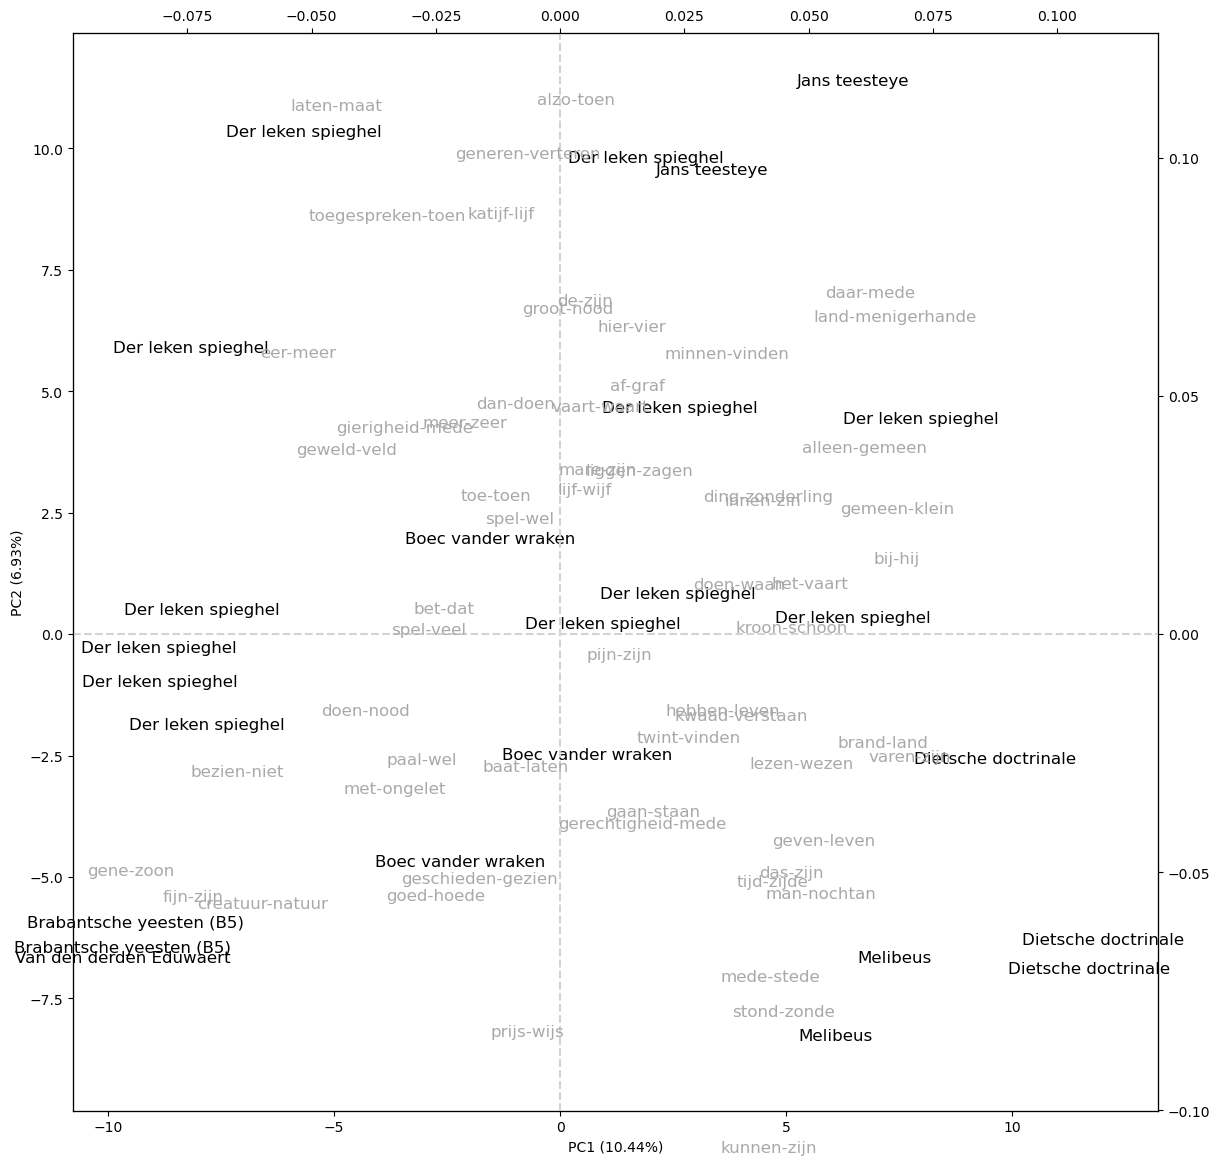

In [63]:
def plot_pca(document_proj, loadings, var_exp, labels):
    # first the texts:
    fig, text_ax = plt.subplots(figsize=(14, 14))
    x1, x2 = documents_proj[:, 0], documents_proj[:, 1]
    text_ax.scatter(x1, x2, facecolors='none')
    for p1, p2, label in zip(x1, x2, labels):
        text_ax.text(p1, p2, label, ha='center', va='center', fontsize=12)

    # add variance information to the axis labels:
    text_ax.set_xlabel(f'PC1 ({var_exp[0] * 100:.2f}%)')
    text_ax.set_ylabel(f'PC2 ({var_exp[1] * 100:.2f}%)')
    
    # now the loadings:
    loadings_ax = text_ax.twinx().twiny()
    l1, l2 = loadings[:, 0], loadings[:, 1]
    lc = l1 * l2
    m = 60
    top_idxs = lc.argsort()[::-1][:m]
    
    loadings_ax.scatter(l1[top_idxs], l2[top_idxs], facecolors='none');
    for x, y, loading in zip(l1, l2, np.array(vectorizer.get_feature_names_out())[top_idxs]):
        loadings_ax.text(x, y, loading, ha='center', va='center',
                         color='darkgrey', fontsize=12)

    mpl_axes_aligner.align.yaxes(text_ax, 0, loadings_ax, 0)
    mpl_axes_aligner.align.xaxes(text_ax, 0, loadings_ax, 0)
    
    # add lines through origins:
    plt.axvline(0, ls='dashed', c='lightgrey', zorder=0)
    plt.axhline(0, ls='dashed', c='lightgrey', zorder=0);

# fit the pca:
pca = PCA(n_components=2)
documents_proj = pca.fit_transform(BOW)
loadings = pca.components_.transpose()
var_exp = pca.explained_variance_ratio_

plot_pca(documents_proj, loadings, var_exp, sub_df['title'])

## Hierarchical clustering

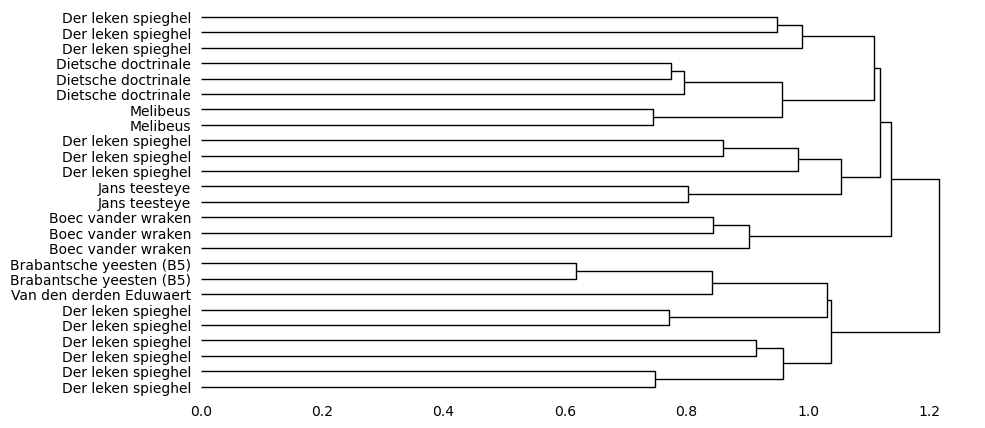

In [64]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as hierarchy

# reset index to ensure sequential indices for hierarchical clustering
trg_reset_df = trg_df.reset_index(drop=True)

# generate labels from the reset DataFrame
labels = trg_reset_df['title'].tolist()

# calculate pairwise distances
dm = scidist.pdist(BOW, 'cosine')

# branch structure
linkage_object = hierarchy.linkage(dm, method='complete')

# visualize
def plot_tree(linkage_object, labels, figsize=(10, 5), ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    with plt.rc_context({'lines.linewidth': 1.0}):
        hierarchy.dendrogram(
            linkage_object, 
            labels=labels, 
            ax=ax,
            link_color_func=lambda c: 'black',
            orientation='right',
            leaf_font_size=10)
    # Remove ticks and spines
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    for s in ax.spines.values():
        s.set_visible(False)

plot_tree(linkage_object, labels)

Some observations:

* Der leken spieghel is scattered in the entire network. It seems to be the most typical or representative/average manifestation of the writing style of Boendale;
* Brabantsche yeesten and Van den derden Eduwaert cluster toghether again, but aren't outsiders;
* Melibeus and Dietsche doctrinaele blend together, partially with der Leken Spieghel.

## Verification Ranking

In [65]:
params = {'use_idf': True,
          'max_features': 500,
          'analyzer': bigrams,
          'min_df': 2}

vectorizer = TfidfVectorizer(**params)
epics = segment_df[segment_df['genre'] == 'Epiek'].copy().reindex()
vectorizer.fit(epics['text'])
segment_X = vectorizer.transform(epics['text']).toarray()
segment_X.shape

(376, 500)

In [66]:
num_iter = 250
total_features = len(vectorizer.get_feature_names_out())
num_rnd_features = int(total_features * .5)
n_top_neighbors = 5

target_titles = [#'Brabantsche yeesten (B1-3)', 'Brabantsche yeesten (B4-5)',
                 'Brabantsche yeesten (B5)', 'Van den derden Eduwaert', 
                 'Der leken spieghel', 'Jans teesteye', 'Boec vander wraken',
                 'Melibeus', 'Dietsche doctrinale',
                 'Der ystorien bloeme', 'Grimbergse oorlog'
                ]

results = []

for target_title in target_titles:
    targets = epics[epics['title'] == target_title]
    candidates = epics[epics['title'] != target_title]
    neighbors = Counter()
    for trg_idx in tqdm(list(targets.index), desc=target_title):
        for i in range(num_iter):
            feats = np.random.choice(total_features, num_rnd_features, replace=False)
            ax = segment_X[trg_idx, feats]
            sampled = candidates.groupby('title').sample(1)
            xx = segment_X[sampled.index][:, feats]
            distances = scidist.cdist([ax], xx, metric='cosine').flatten()
            idxs = distances.argsort()[:1]
            neighbors.update(sampled.iloc[idxs]['title'])
    top_neighbors = neighbors.most_common(n_top_neighbors)
    summed = sum(neighbors.values())
    top_neighbors = [f'{k} ({(v / summed) * 100:.2f}%)' for k, v in top_neighbors]
    
    results.append([target_title] + top_neighbors)
    
results = pd.DataFrame(results, columns=['Target']+[f'Rank {i + 1}' for i in range(n_top_neighbors)])
results

Grimbergse oorlog: 100%|██████████████████████████| 5/5 [00:00<00:00,  5.77it/s]


,Target,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5
0,Brabantsche yeesten (B5),Van den derden Eduwaert (86.40%),Brabantsche yeesten (B1-3) (3.80%),Roman der Lorreinen II (2.20%),Spiegel historiael (P4) (1.20%),Boec vander wraken (1.00%)
1,Van den derden Eduwaert,Brabantsche yeesten (B5) (88.40%),Brabantsche yeesten (B1-3) (5.20%),Boec vander wraken (3.60%),Spiegel historiael (P4) (0.80%),Rijmkroniek van Woeringen (0.40%)
2,Der leken spieghel,Boec vander wraken (22.73%),Dietsche doctrinale (20.43%),Jans teesteye (16.07%),Melibeus (7.70%),Brabantsche yeesten (B4-5) (7.33%)
3,Jans teesteye,Dietsche doctrinale (49.60%),Melibeus (20.80%),Boec vander wraken (18.40%),Der leken spieghel (10.40%),Brabantsche yeesten (B6) (0.20%)
4,Boec vander wraken,Jans teesteye (33.60%),Melibeus (21.20%),Dietsche doctrinale (17.07%),Der leken spieghel (11.33%),Van den derden Eduwaert (8.27%)
5,Melibeus,Dietsche doctrinale (88.40%),Boec vander wraken (5.80%),Jans teesteye (3.20%),Der leken spieghel (1.80%),Der mannen ende vrouwen heimelijcheit (0.40%)
6,Dietsche doctrinale,Melibeus (83.73%),Jans teesteye (8.13%),Der leken spieghel (5.20%),Boec vander wraken (1.73%),Enaamse Codex (0.53%)
7,Der ystorien bloeme,Boec vander wraken (21.20%),Van den derden Eduwaert (12.00%),Spiegel historiael (P4) (7.20%),Brabantsche yeesten (B5) (5.80%),Grimbergse oorlog (5.60%)
8,Grimbergse oorlog,Brabantsche yeesten (B5) (18.00%),Renout van Montalbaen (11.36%),Roman der Lorreinen II (11.04%),Van den derden Eduwaert (8.80%),Rijmkroniek van Woeringen (8.24%)


## Feature analysis

On the Antwerp School (vs. all Middle Dutch historiographic/didactic works)

In [70]:
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel', 'Jans teesteye', 
    'Van den derden Eduwaert', 'Melibeus',
    'Dietsche doctrinale', 'Boec vander wraken'
]

# control
control = (
    epics['subgenre'].isin(['Historiografie', 'Didactiek']) &
    ~epics['title'].isin(target_titles)
)

# Use the filtered indices to subset segment_X
control = epics[control].index
all_indices = epics.index[epics['title'].isin(target_titles)].tolist() + control.tolist()

# Build BOW from targets + filtered comparison texts
BOW = pd.DataFrame(segment_X[all_indices], columns=vectorizer.get_feature_names_out())
BOW.index = epics.loc[all_indices, 'title'].isin(target_titles)

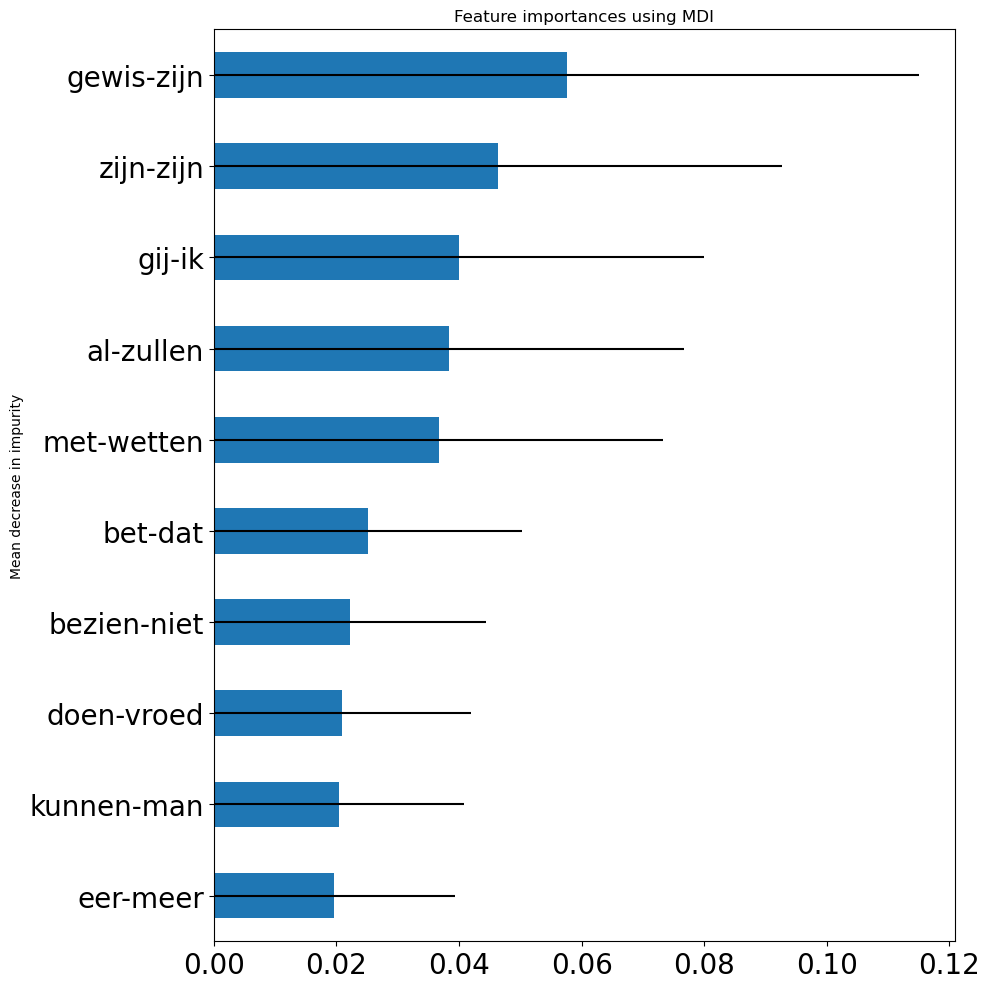

In [71]:
classes = BOW.index

feature_names = vectorizer.get_feature_names_out()
forest = RandomForestClassifier(random_state=0)
forest.fit(BOW, classes)

importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

cutoff = 10
forest_importances = pd.Series(importances, index=feature_names)
std = pd.Series(std, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(cutoff)[::-1]
std = forest_importances.loc[forest_importances.index].head(cutoff)[::-1]

fig, ax = plt.subplots(figsize=(10, 10))
forest_importances.plot.barh(xerr=std, ax=ax, fontsize=20)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

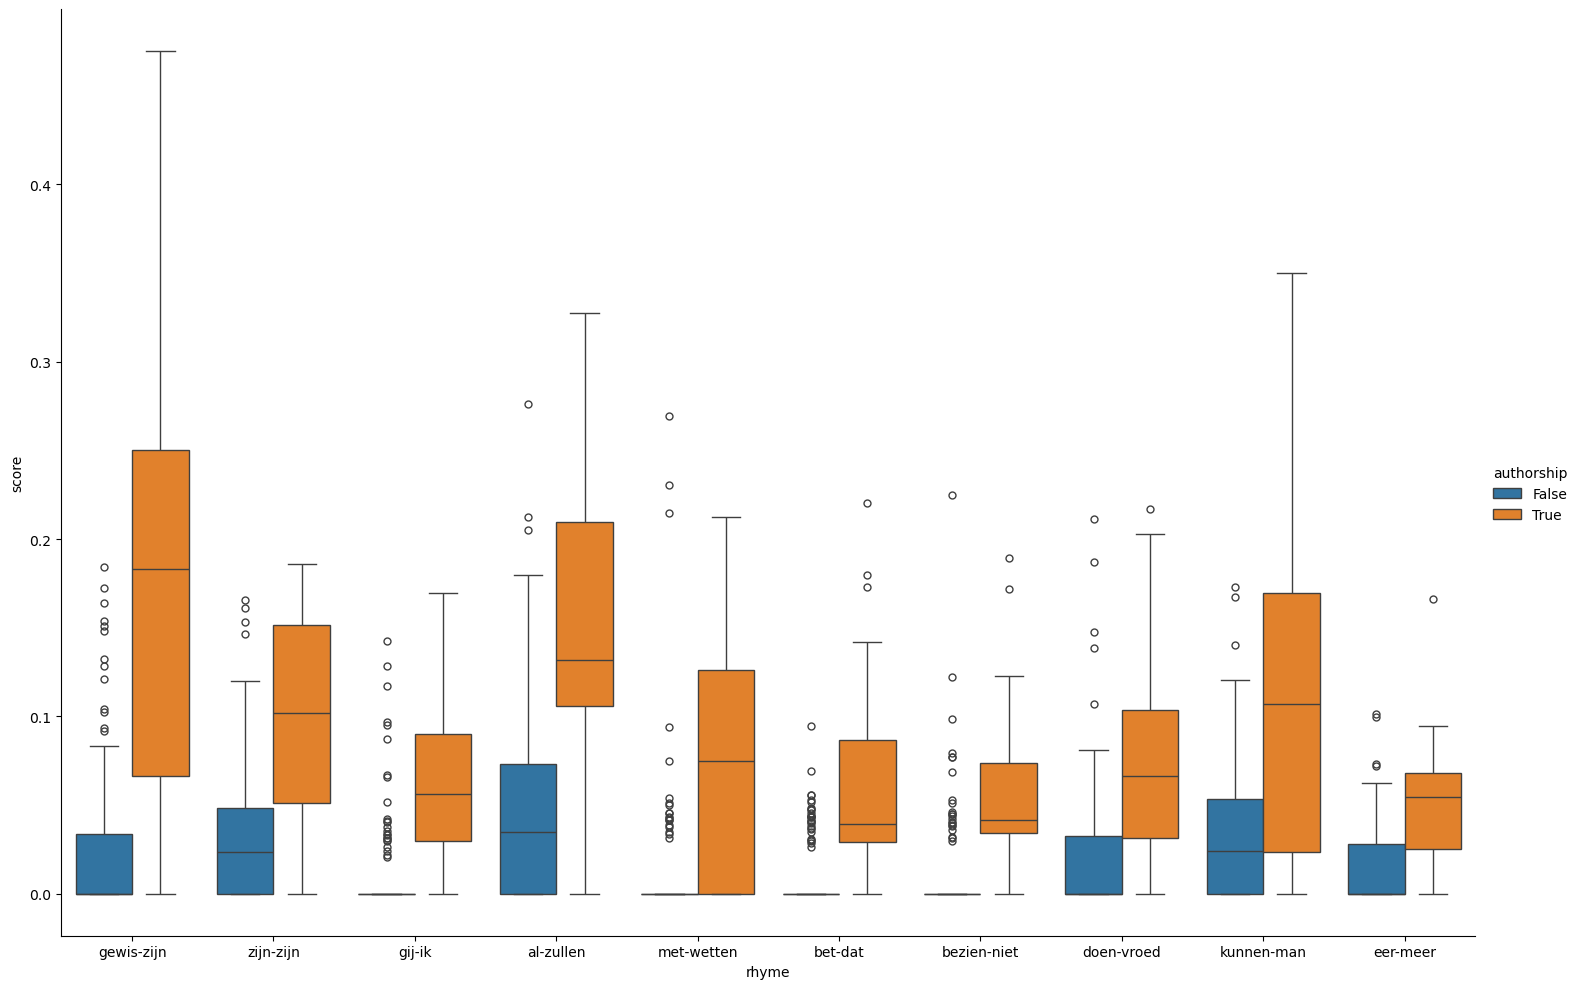

In [72]:
BOW = BOW[forest_importances.index[::-1]]
BOW.index = classes
bow = pd.melt(BOW, value_vars=BOW.columns, ignore_index=False, var_name='rhyme', value_name='score')
bow = bow.reset_index()
bow['authorship'] = bow['title']
sb.catplot(x="rhyme", hue="authorship", y="score", data=bow, kind='box', height=10, aspect=1.5);

On a particular work: Jans teesteye vs. Antwerp School

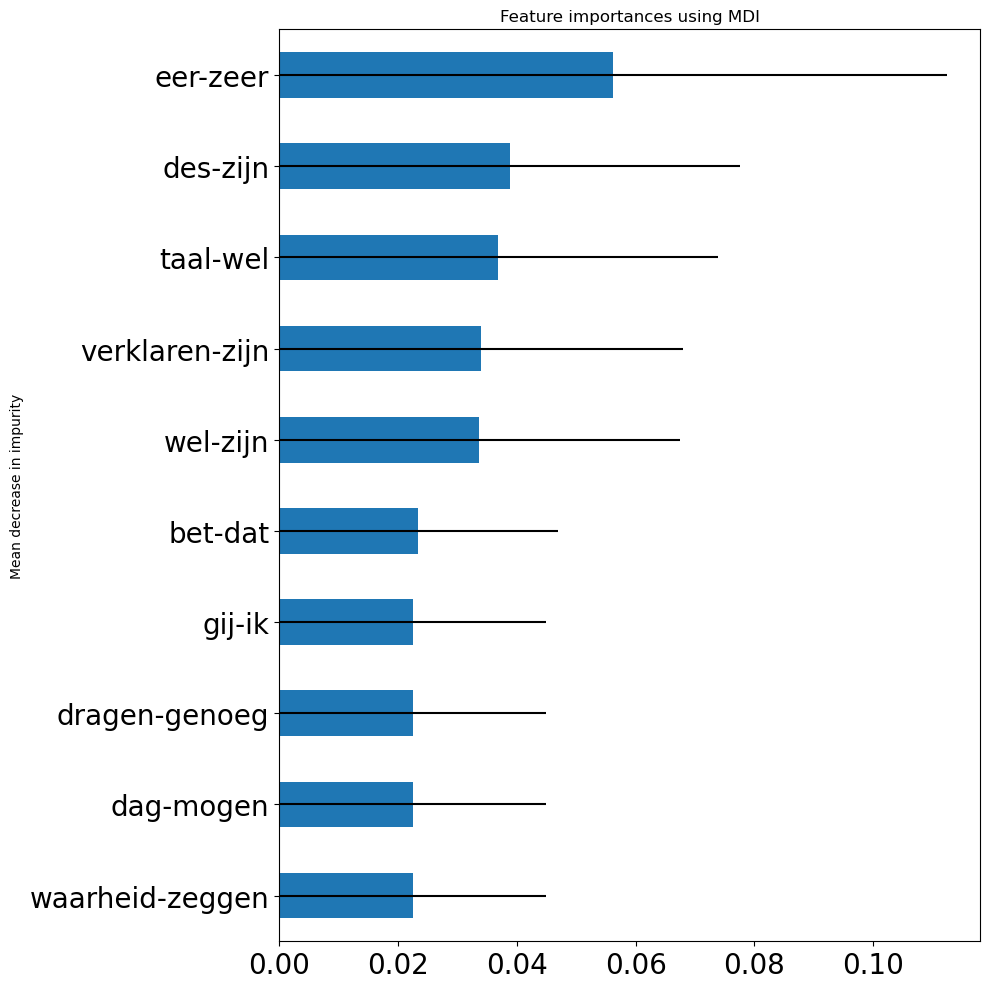

In [73]:
epics = epics[epics['title'].isin([#'Brabantsche yeesten (B1-3)', 
                                   #'Brabantsche yeesten (B4-5)',
                                   'Brabantsche yeesten (B5)',
                                   'Der leken spieghel', 'Jans teesteye', 'Van den derden Eduwaert', 
                                   'Melibeus',
                                   'Dietsche doctrinale', 'Boec vander wraken'])]

segment_X = vectorizer.transform(epics['text']).toarray()

BOW = pd.DataFrame(segment_X, columns=vectorizer.get_feature_names_out())
BOW.index = epics['title'] == 'Jans teesteye' # target

classes = BOW.index

feature_names = vectorizer.get_feature_names_out()
forest = RandomForestClassifier(random_state=0)
forest.fit(BOW, classes)

importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

cutoff = 10
forest_importances = pd.Series(importances, index=feature_names)
std = pd.Series(std, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(cutoff)[::-1]
std = forest_importances.loc[forest_importances.index].head(cutoff)[::-1]

fig, ax = plt.subplots(figsize=(10, 10))
forest_importances.plot.barh(xerr=std, ax=ax, fontsize=20)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

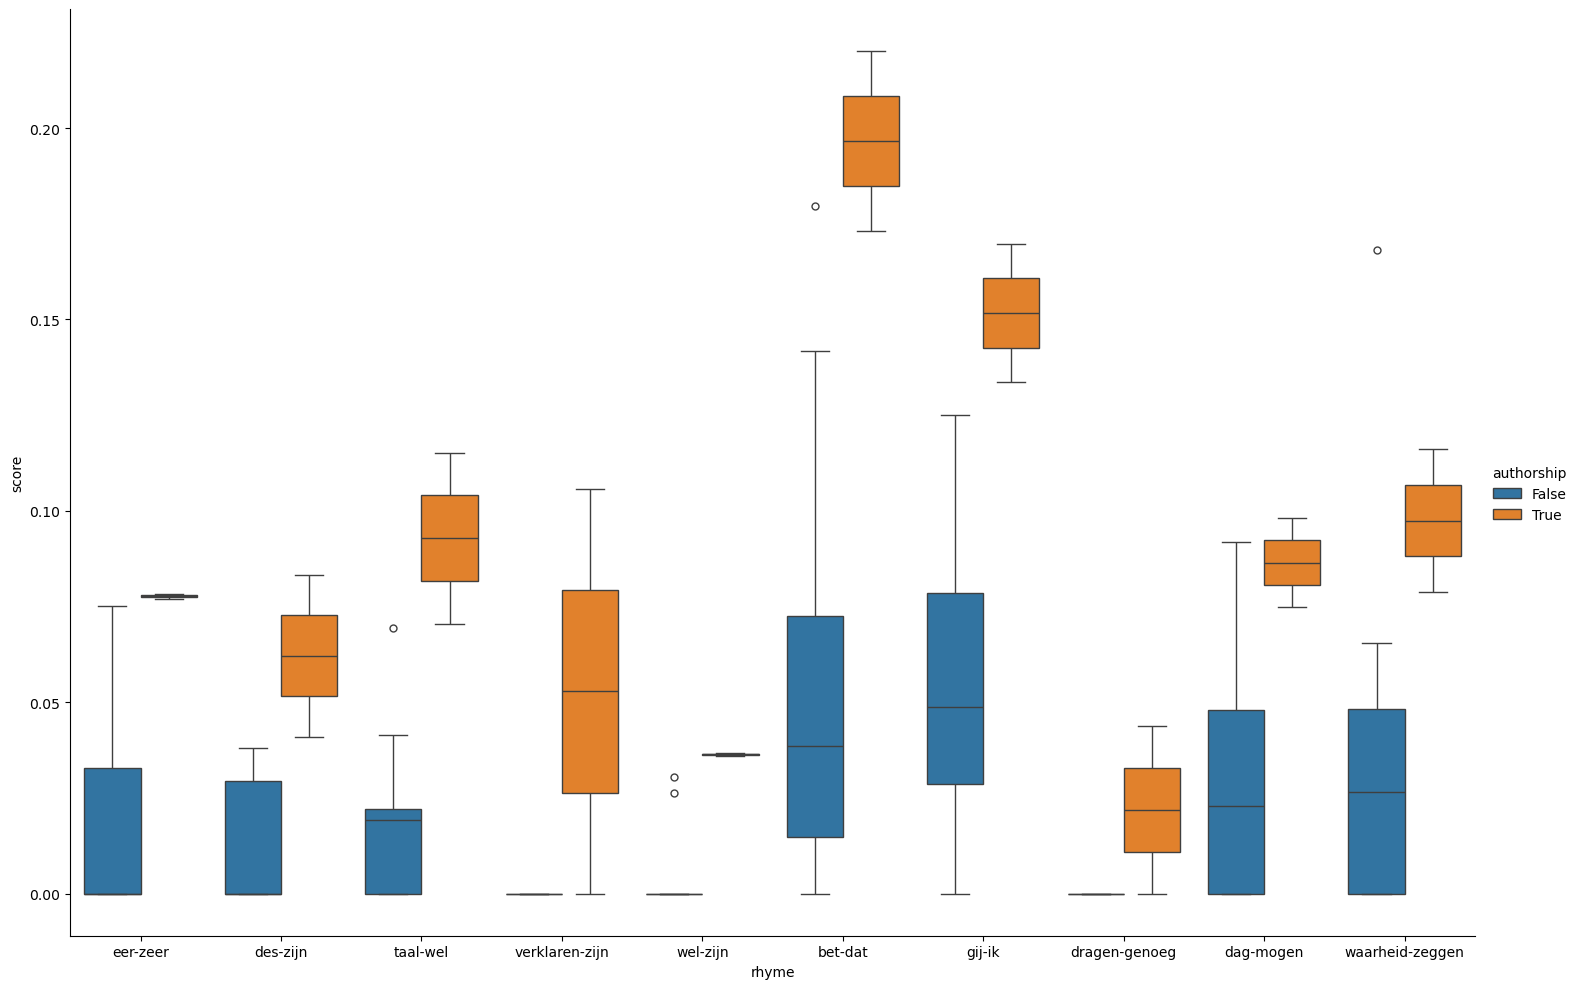

In [74]:
BOW = BOW[forest_importances.index[::-1]]
BOW.index = classes
bow = pd.melt(BOW, value_vars=BOW.columns, ignore_index=False, var_name='rhyme', value_name='score')
bow = bow.reset_index()
bow['authorship'] = bow['title']
sb.catplot(x="rhyme", hue="authorship", y="score", data=bow, kind='box', height=10, aspect=1.5);